## EV Route Finding System

## Initial Neighbor Finding Code

In [1]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import random
from sklearn.cluster import DBSCAN
import numpy as np
from collections import defaultdict
import math
import pickle

In [ ]:
# Keep only stations with valid coordinates and charger counts
df = pd.read_csv("./ev-charging-station.csv")
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'EV Level2 EVSE Num', 'EV Connector Types']).reset_index(drop=True)
df_clean['EV Level2 EVSE Num'] = df_clean['EV Level2 EVSE Num'].astype(int)

# Parse connector types into sets
df_clean['connector_set'] = df_clean['EV Connector Types'].apply(lambda x: set(map(str.strip, x.split(','))) if isinstance(x, str) else set())

# Clustering
coords = df_clean[['Latitude', 'Longitude']].to_numpy()
kms_per_radian = 6371.0088
epsilon = 20.0 / kms_per_radian  # ~20 km radius
db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
df_clean['cluster'] = db.labels_

# Group by cluster and aggregate
df_clustered = df_clean.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'EV Level2 EVSE Num': 'sum',
    'connector_set': lambda sets: set().union(*sets)
}).reset_index(drop=True)

G = nx.Graph()
for idx, row in df_clustered.iterrows():
    G.add_node(
        idx,
        pos=(row['Latitude'], row['Longitude']),
        chargers=row['EV Level2 EVSE Num'],
        connector_types=row['connector_set']
    )

def distance(i, j):
    return geodesic(G.nodes[i]['pos'], G.nodes[j]['pos']).km

def angle_between(lat1, lon1, lat2, lon2):
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    angle = math.degrees(math.atan2(dlon, dlat)) % 360
    return angle

# number of nearest neighbors per node
k = 5

print("Graph node count:", len(G.nodes))
print("Connecting each node to its", k, "nearest neighbors...")

for i in G.nodes:
    distances = []
    lat1, lon1 = G.nodes[i]['pos']

    for j in G.nodes:
        if i == j:
            continue
        lat2, lon2 = G.nodes[j]['pos']
        dist = distance(i, j)
        distances.append((dist, j))

    distances.sort()
    nearest_neighbors = [j for _, j in distances[:k]]

    for j in nearest_neighbors:
        dist = distance(i, j)
        weight = dist / (1 + G.nodes[j]['chargers'])
        G.add_edge(i, j, weight=weight)

    print(f"Node {i} → Neighbors: {nearest_neighbors}")

# Save
with open("graph_data.gpickle", "wb") as f:
    pickle.dump(G, f)

C:\Users\Sarvesh Ram Kumar\AppData\Local\Temp\ipykernel_8252\3988376000.py:2: DtypeWarning: Columns (5,6,26,38,48,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./ev-charging-station.csv")


Graph node count: 2076
Connecting each node to its 5 nearest neighbors...
Node 0 → Neighbors: [743, 101, 131, 1464, 773]
Node 1 → Neighbors: [1723, 2048, 1544, 1995, 845]
Node 2 → Neighbors: [1601, 725, 578, 718, 228]
Node 3 → Neighbors: [470, 1591, 255, 817, 162]
Node 4 → Neighbors: [372, 556, 249, 300, 1042]
Node 5 → Neighbors: [1174, 908, 1254, 359, 191]
Node 6 → Neighbors: [929, 473, 315, 1807, 740]
Node 7 → Neighbors: [1874, 1718, 1034, 1101, 651]
Node 8 → Neighbors: [557, 348, 1877, 1833, 1430]
Node 9 → Neighbors: [1889, 1165, 1360, 595, 625]
Node 10 → Neighbors: [591, 1158, 528, 1751, 700]
Node 11 → Neighbors: [609, 1105, 342, 1663, 1373]
Node 12 → Neighbors: [1484, 1261, 1647, 1059, 1498]
Node 13 → Neighbors: [1576, 1626, 545, 468, 1548]
Node 14 → Neighbors: [798, 1590, 1231, 1800, 1129]
Node 15 → Neighbors: [1102, 523, 282, 1891, 1868]
Node 16 → Neighbors: [1778, 467, 1210, 1224, 1117]
Node 17 → Neighbors: [1554, 1773, 1959, 1479, 881]
Node 18 → Neighbors: [1871, 582, 1084, 19

In [2]:
# Load
with open("graph_data.gpickle", "rb") as f:
    G = pickle.load(f)

## The Environment the Car is going to work upon and Double Q-Learning Algorithm

In [3]:
class EVRouteEnv:
    def __init__(self, graph, start, goal, preferred_connector_type=None):
        self.graph = graph
        self.start = start
        self.goal = goal
        self.state = start
        self.visited = set()
        self.steps = 0
        self.prev_distance_to_goal = float('inf')
        self.distance = 0
        self.visit_counts = defaultdict(int)
        self.preferred_connector_type = preferred_connector_type

    def reset(self):
        self.state = self.start
        self.visited = {self.start}
        self.steps = 0
        self.prev_distance_to_goal = float('inf')
        self.distance = 0
        self.visit_counts.clear()
        return self.state

    def step(self, action):
        if action not in self.graph[self.state]:
            return self.state, -10, False

        self.steps += 1
        prev_pos = self.graph.nodes[self.state]['pos']
        next_pos = self.graph.nodes[action]['pos']
        dist_traveled = geodesic(prev_pos, next_pos).km
        self.distance += dist_traveled

        reward = -dist_traveled

        # Connector-aware charger reward
        node_data = self.graph.nodes[action]
        if node_data.get('chargers', 0) > 0:
            connectors = node_data.get('connector_types', [])
            if self.preferred_connector_type in connectors:
                reward += 10  # Big bonus for preferred connector
            else:
                reward -= 3  # Slight penalty if no preferred connector

        # Reward for progress toward goal
        prev_goal_dist = geodesic(prev_pos, self.graph.nodes[self.goal]['pos']).km
        new_goal_dist = geodesic(next_pos, self.graph.nodes[self.goal]['pos']).km
        reward += 0.5 * (prev_goal_dist - new_goal_dist)

        # Delay penalty
        reward -= min(0.01 * (1.05 ** self.steps), 900)

        # Looping penalty
        if action in self.visited:
            visits = self.visit_counts.get(action, 1)
            reward -= 100 * visits
            self.visit_counts[action] = visits + 1
        else:
            self.visit_counts[action] = 1

        self.state = action
        self.visited.add(action)

        done = self.state == self.goal
        if done:
            reward += 10000

        return self.state, reward, done

    def get_actions(self, state):
        return list(self.graph[state])

class DoubleQLearningAgent:
    def __init__(self, graph, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.Q1 = defaultdict(float)
        self.Q2 = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.graph = graph

    def get_q(self, table, state, action):
        return table.get((state, action), 0.0)

    def choose_action(self, state, actions):
        if random.random() < self.epsilon:
            return random.choice(actions)
        q_values = [(self.Q1[(state, a)] + self.Q2[(state, a)]) / 2 for a in actions]
        max_q = max(q_values)
        return actions[q_values.index(max_q)]

    def learn(self, s, a, r, s_, actions_s_):
        if random.random() < 0.5:
            # Update Q1
            best_action = max(actions_s_, key=lambda x: self.Q1[(s_, x)])
            target = r + self.gamma * self.Q2[(s_, best_action)]
            self.Q1[(s, a)] += self.alpha * (target - self.Q1[(s, a)])
        else:
            # Update Q2
            best_action = max(actions_s_, key=lambda x: self.Q2[(s_, x)])
            target = r + self.gamma * self.Q1[(s_, best_action)]
            self.Q2[(s, a)] += self.alpha * (target - self.Q2[(s, a)])
            
def find_nearest_node(lat, lon):
    return min(G.nodes, key=lambda n: geodesic((lat, lon), G.nodes[n]['pos']).km)

## Training on the Dataset with 600 Episodes with Starting and Destination Locations

In [4]:
start_lat, start_lon = 28.54, -81.37   # Orlando, FL (approx.)
end_lat, end_lon = 33.75, -84.39       # Atlanta, GA (approx.)

start_node = find_nearest_node(start_lat, start_lon)
goal_node = find_nearest_node(end_lat, end_lon)

env = EVRouteEnv(G, start_node, goal_node, preferred_connector_type='J1772')
max_steps = 10000

agent = DoubleQLearningAgent(G)

import matplotlib.pyplot as plt

# Initialize lists to track episode metrics
episode_distances = []
episode_rewards = []
episode_steps = []

for episode in range(600):
    state = env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done and steps < max_steps:
        actions = env.get_actions(state)
        if not actions:
            break  # no available actions

        action = agent.choose_action(state, actions)
        next_state, reward, done = env.step(action)

        next_actions = env.get_actions(next_state)
        agent.learn(state, action, reward, next_state, next_actions)

        state = next_state
        total_reward += reward
        steps += 1

    episode_distances.append(env.distance)
    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    print(f"Episode {episode+1}: Total distance = {env.distance:.2f} km, steps = {steps}, Total reward = {total_reward:.2f}")



Episode 1: Total distance = 10204.76 km, steps = 124, Total reward = -17499.71
Episode 2: Total distance = 12663.79 km, steps = 181, Total reward = -35523.76
Episode 3: Total distance = 37227.49 km, steps = 680, Total reward = -569140.17
Episode 4: Total distance = 6020.21 km, steps = 95, Total reward = -8133.73
Episode 5: Total distance = 6074.64 km, steps = 97, Total reward = -1718.38
Episode 6: Total distance = 5340.40 km, steps = 76, Total reward = 56.15
Episode 7: Total distance = 2754.72 km, steps = 43, Total reward = 3696.68
Episode 8: Total distance = 85035.74 km, steps = 1453, Total reward = -1560272.42
Episode 9: Total distance = 7912.63 km, steps = 111, Total reward = -11491.75
Episode 10: Total distance = 33834.15 km, steps = 109, Total reward = -46027.88
Episode 11: Total distance = 193455.61 km, steps = 3026, Total reward = -3500416.29
Episode 12: Total distance = 6772.53 km, steps = 108, Total reward = -10401.22
Episode 13: Total distance = 3083.00 km, steps = 50, Total 

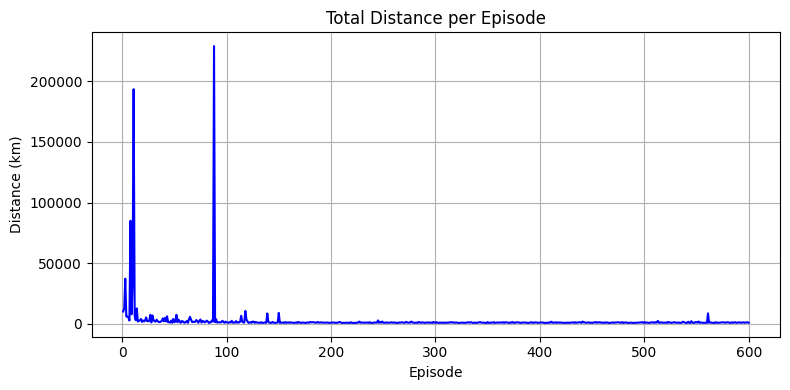

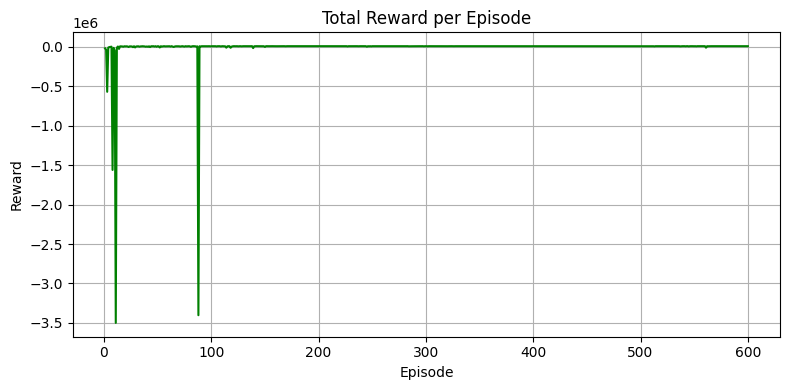

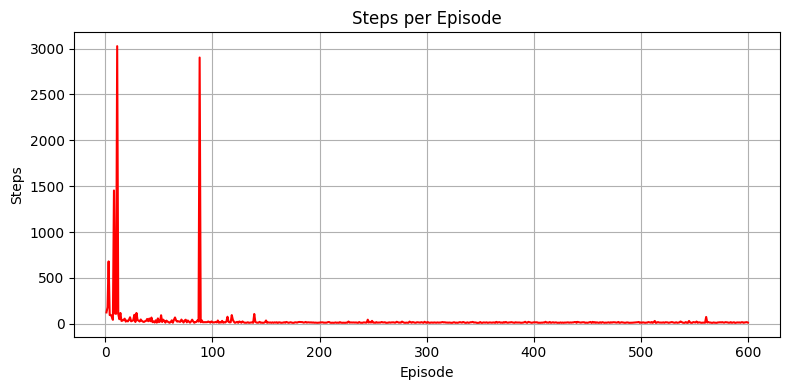

In [5]:
import matplotlib.pyplot as plt

episodes = range(1, len(episode_distances) + 1)

# 1. Distance Plot
plt.figure(figsize=(8, 4))
plt.plot(episodes, episode_distances, color='blue')
plt.title("Total Distance per Episode")
plt.xlabel("Episode")
plt.ylabel("Distance (km)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Reward Plot
plt.figure(figsize=(8, 4))
plt.plot(episodes, episode_rewards, color='green')
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Steps Plot
plt.figure(figsize=(8, 4))
plt.plot(episodes, episode_steps, color='red')
plt.title("Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.tight_layout()
plt.show()


## Filtering Nodes Selected

In [6]:
def filter_path_by_distance(path, graph, min_km=175, max_km=225):
    if not path or len(path) < 2:
        return path

    filtered_path = [path[0]]
    current = path[0]
    i = 1

    while i < len(path):
        found = False
        for j in range(i, len(path)):
            dist = geodesic(graph.nodes[current]['pos'], graph.nodes[path[j]]['pos']).km
            if min_km <= dist <= max_km:
                filtered_path.append(path[j])
                current = path[j]
                i = j + 1
                found = True
                break
        if not found:
            filtered_path.append(path[i])
            current = path[i]
            i += 1

    return filtered_path


## Testing with the same route to get results

In [7]:
# Set epsilon to 0 for greedy action selection (no exploration)
agent.epsilon = 0.0

# Reset environment and initialize path tracking
state = env.reset()
path = [state]
step_counter = 0
max_steps = 1000  

with open("ev_route_coordinates_double_q.txt", "w") as f:
    done = False
    while not done and step_counter < max_steps:
        actions = env.get_actions(state)
        if not actions:
            print("No further actions available.")
            break

        action = agent.choose_action(state, actions)
        state, _, done = env.step(action)
        path.append(state)

        lat, lon = G.nodes[state]['pos']
        f.write(f"{lon},{lat}\n")
        print(f"Step {step_counter + 1}: Moving to {lon},{lat}")

        step_counter += 1

print("Route completed.")
print(f"Total distance traveled: {env.distance:.2f} km")

# Check final destination accuracy
goal_lat, goal_lon = G.nodes[env.goal]['pos']
final_lat, final_lon = G.nodes[state]['pos']
remaining_dist = geodesic((final_lat, final_lon), (goal_lat, goal_lon)).km

print(f"Reached node: {state}")
print(f"Goal node: {env.goal}")
print(f"Distance to goal: {remaining_dist:.2f} km")

if remaining_dist < 5.0:
    print("Agent successfully reached the goal.")
else:
    print("Agent did NOT reach the goal accurately.")

Step 1: Moving to -82.18665229506666,29.162481371888887
Step 2: Moving to -82.35254862084442,29.64541631787553
Step 3: Moving to -82.63096329999999,30.1780853
Step 4: Moving to -82.768997,31.031873
Step 5: Moving to -83.52709487982396,31.449144219852315
Step 6: Moving to -83.750007,31.959368
Step 7: Moving to -83.66284706363636,32.603469372727275
Step 8: Moving to -83.66639883178377,32.887384162693344
Step 9: Moving to -83.3232515,33.468328
Step 10: Moving to -83.39266520374737,33.94462319562608
Step 11: Moving to -84.32069266741782,33.869445938113344
Route completed.
Total distance traveled: 790.56 km
Reached node: 6
Goal node: 6
Distance to goal: 0.00 km
Agent successfully reached the goal.


## Geodesic Analysis

In [8]:
print("Geodesic Analysis")

# To find the final accuaracy comparing the original actual distances with the travelled distance by the car
actual_geodesic = geodesic(G.nodes[start_node]['pos'], G.nodes[goal_node]['pos']).km
efficiency = actual_geodesic / env.distance
print(f"Accuracy (efficiency): {efficiency:.2%}")

filtered_path = filter_path_by_distance(path, G)
print(f"\nFiltered Path (hops 175–225 km): {filtered_path}")

filtered_distance = sum(
    geodesic(G.nodes[filtered_path[i]]['pos'], G.nodes[filtered_path[i + 1]]['pos']).km
    for i in range(len(filtered_path) - 1)
)
#print(f"Filtered path total distance: {filtered_distance:.2f} km")

filtered_efficiency = actual_geodesic / filtered_distance
print(f"Filtered Accuracy (efficiency): {filtered_efficiency:.2%}")

# Save filtered path coordinates to a text file
with open("ev-routing-coordinates-double-q-filtering.txt", "w") as f:
    for node in filtered_path:
        lat, lon = G.nodes[node]['pos']  # assuming 'pos' is in (lat, lon) format
        f.write(f"{lon},{lat}\n") 

print("\nOn-Road Distance Comparison")
on_road=710
print(f"Actual Accuracy:{(on_road/env.distance):.2%}")

Geodesic Analysis
Accuracy (efficiency): 84.98%

Filtered Path (hops 175–225 km): [16, 1117, 805, 257, 1181, 527, 315, 6]
Filtered Accuracy (efficiency): 87.87%

On-Road Distance Comparison
Actual Accuracy:89.81%


## On-Road Distance Analysis(Actual Accuracy of the Model) using ORS:

Route from point 0 to 1: 123093.70 m
Route from point 1 to 2: 248967.00 m
Route from point 2 to 3: 238314.10 m
Route from point 3 to 4: 43978.20 m
Route from point 4 to 5: 93024.70 m
Route from point 5 to 6: 78230.40 m
Route from point 6 to 7: 99464.80 m

✅ Total real-world road distance: 925.07 km


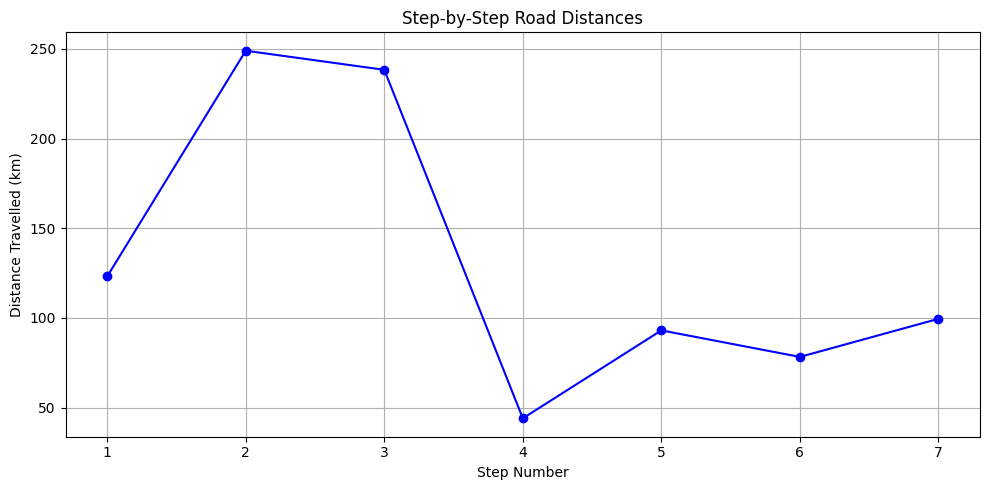

In [ ]:
import openrouteservice

# Replace with your actual OpenRouteService API key
ORS_API_KEY = "API-key"

# Load coordinates (in (lat, lon) format)
coords = []
with open("ev-routing-coordinates-double-q-filtering.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        coords.append((lon, lat))  # ORS expects (lon, lat)

# Initialize ORS client
client = openrouteservice.Client(key=ORS_API_KEY)

# Calculate total road distance
total_distance = 0
start_idx = 0
step_distances = []

for end_idx in range(1, len(coords)):
    try:
        res = client.directions(
            coordinates=[coords[start_idx], coords[end_idx]],
            profile='driving-car',
            format='geojson',
            radiuses=[1000, 1000]
        )
        dist = res['features'][0]['properties']['segments'][0]['distance']  # in meters
        total_distance += dist
        step_distances.append(dist / 1000)  # convert to kilometers
        print(f"Route from point {start_idx} to {end_idx}: {dist:.2f} m")

        start_idx = end_idx  # Move to next valid start point
    except Exception as e:
        print(f"⚠️ No route from point {start_idx} to {end_idx}: skipping point {end_idx}")

print(f"\n✅ Total real-world road distance: {total_distance/1000:.2f} km")

# Plot step-wise distances
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(step_distances)+1), step_distances, marker='o', linestyle='-', color='blue')
plt.title("Step-by-Step Road Distances")
plt.xlabel("Step Number")
plt.ylabel("Distance Travelled (km)")
plt.grid(True)
plt.xticks(range(1, len(step_distances)+1))
plt.tight_layout()
plt.show()


## Finding the Actual Accuracy of the Model

In [10]:
on_road_distance = 710
total_distance=total_distance/1000
actual_accuracy = on_road_distance / total_distance
print(f"Actual Accuracy (Efficiency): {actual_accuracy:.2%}")

Actual Accuracy (Efficiency): 76.75%


## Plotting with Filtering

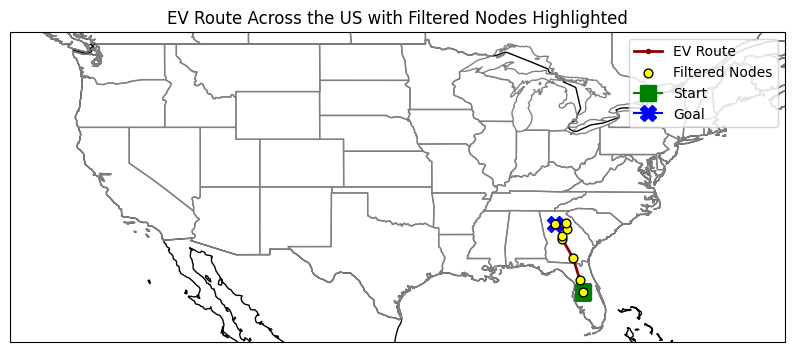

In [11]:
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load full route coordinates
route_coords = []
with open("ev-routing-coordinates-double-q-filtering.txt", "r") as f:
    for line in f:
        lon, lat = map(float, line.strip().split(','))
        route_coords.append((lon, lat))

# Load filtered node positions (from graph G using node IDs)
filtered_coords = [G.nodes[n]['pos'] for n in filtered_path]
filtered_lats, filtered_lons = zip(*filtered_coords)

# Split full route coords
lons, lats = zip(*route_coords)

# Set up map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES, edgecolor='gray')

# Plot full route
ax.plot(lons, lats, marker='o', color='darkred', linewidth=2, markersize=3, label='EV Route')

# Highlight filtered path nodes
ax.scatter(filtered_lons, filtered_lats, color='yellow', edgecolor='black', s=40, zorder=5, label='Filtered Nodes')

# Mark start and goal
ax.plot(lons[0], lats[0], marker='s', color='green', markersize=12, label='Start')
ax.plot(lons[-1], lats[-1], marker='X', color='blue', markersize=12, label='Goal')

plt.title("EV Route Across the US with Filtered Nodes Highlighted")
plt.legend()
plt.show()
